# FULLY SYNTHETIC UMAP DATA GENERATION

## Loading libraries and importing packages


In [24]:
import matplotlib.pyplot as plt  # Visualization library
import seaborn as sns
import numpy as np               # Basic mathematics
import os                        # OS options in line with Python
import pandas as pd              # Dataframes library
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.pipeline import make_pipeline
import umap  # pip install umap-learn
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, MaxAbsScaler, Normalizer
from sklearn.neighbors import NearestNeighbors
from matplotlib.patches import Circle
import math
import matplotlib.ticker as ticker
import datetime
from sklearn.model_selection import train_test_split

## Function definition

In [26]:
def mad_centroid(group):
    median = np.median(group, axis=0)
    mad = np.median(np.abs(group - median), axis=0)
    return median


def cluster_CentroidRadius_DensityPercent (X_umap, y, density_th, percent_th):

    classes = np.unique(y)
    umap_clusters = {value: X_umap[y == value] for value in classes} #Dicctionari amb 1:{coordenades de csPCa = 1} i 0:{coordenades de csPCA = 0}
    class_counts = {value: np.sum(y == value) for value in np.unique(y)}

    #Compute centroids
    centroids = {value: mad_centroid(umap_clusters[value]) for value in classes} #Diccionari amb 1:{centroide de csPCa = 1} i 0:{centroide de csPCa = 0}

    distances_to_centroids = []

    for point, value in zip(X_umap, y):
        centroid = centroids[value]
        distance = np.linalg.norm(point - centroid)  # Euclidean distance
        distances_to_centroids.append(distance)
    distances_to_centroids = np.array(distances_to_centroids)  

    radius = {}
    for value in classes:
        percent = 0
        rad = 1
        density = 20
        while not (percent >= percent_th and density <= density_th) :
            rad_def = rad
            rad += 1
            cluster_indices = (y == value)
            cluster_distances = distances_to_centroids[cluster_indices]
            n_samples_rad = np.sum(cluster_distances <= rad)
            area = math.pi*rad**2
            density = n_samples_rad/area
            percent = n_samples_rad/class_counts[value]
        radius[value] = rad_def        

    return centroids, radius

# Load data

In [27]:
picai = pd.read_csv('marksheet_minimal.csv') 
print('The original features are:')
picai_columns=list(picai.columns)
print(list(picai_columns))
picai_psa = picai.drop(["psad", "psad_computed"], axis=1)
picai_col = picai_psa.columns
picai_psa.info()

The original features are:
['patient_age', 'psad', 'psa', 'psad_computed', 'prostate_volume', 'case_csPCa']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_age      1500 non-null   float64
 1   psa              1460 non-null   float64
 2   prostate_volume  1473 non-null   float64
 3   case_csPCa       1500 non-null   float64
dtypes: float64(4)
memory usage: 47.0 KB


In [28]:
#KNN imputation 
knn_imputer = KNNImputer(n_neighbors=10)
picai_psa_imputed = knn_imputer.fit_transform(picai_psa.copy())
picai_psa_imputed = pd.DataFrame(picai_psa_imputed, columns = picai_col )

picai_psa_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_age      1500 non-null   float64
 1   psa              1500 non-null   float64
 2   prostate_volume  1500 non-null   float64
 3   case_csPCa       1500 non-null   float64
dtypes: float64(4)
memory usage: 47.0 KB


## 1.  UMAP Transformation and Feature Distribution


In [29]:
random_state = 23

In [30]:
X_picai, y_picai = picai_psa_imputed.drop(["case_csPCa"], axis=1), picai_psa_imputed[["case_csPCa"]].values.flatten()

norm_pipe = make_pipeline(StandardScaler()).fit(X_picai)
X_norm = norm_pipe.transform(X_picai.copy())
manifold_norm = umap.UMAP(random_state=random_state).fit(X_norm, y_picai)
X_umap_norm = manifold_norm.transform(X_norm)

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


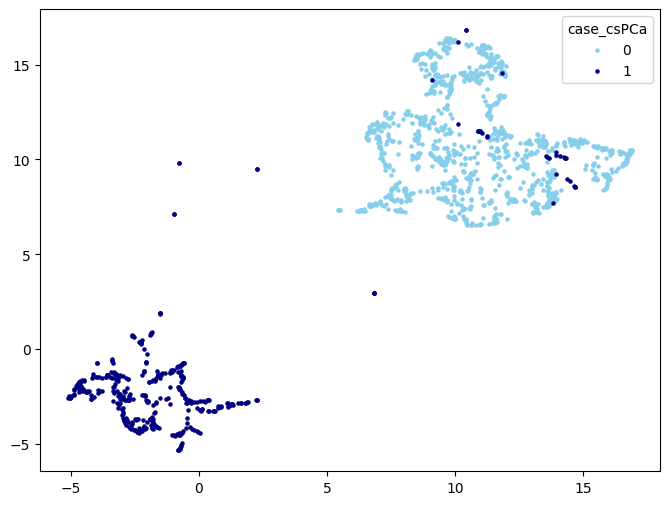

In [31]:
plt.figure(figsize=(8, 6))

class_0_idx = y_picai == 0.0
plt.scatter(X_umap_norm[class_0_idx, 0], X_umap_norm[class_0_idx, 1], c='skyblue', label='0', s=5)

class_1_idx = y_picai == 1.0
plt.scatter(X_umap_norm[class_1_idx, 0], X_umap_norm[class_1_idx, 1], c='navy', label='1', s=5)

plt.legend(title="case_csPCa")

plt.show()

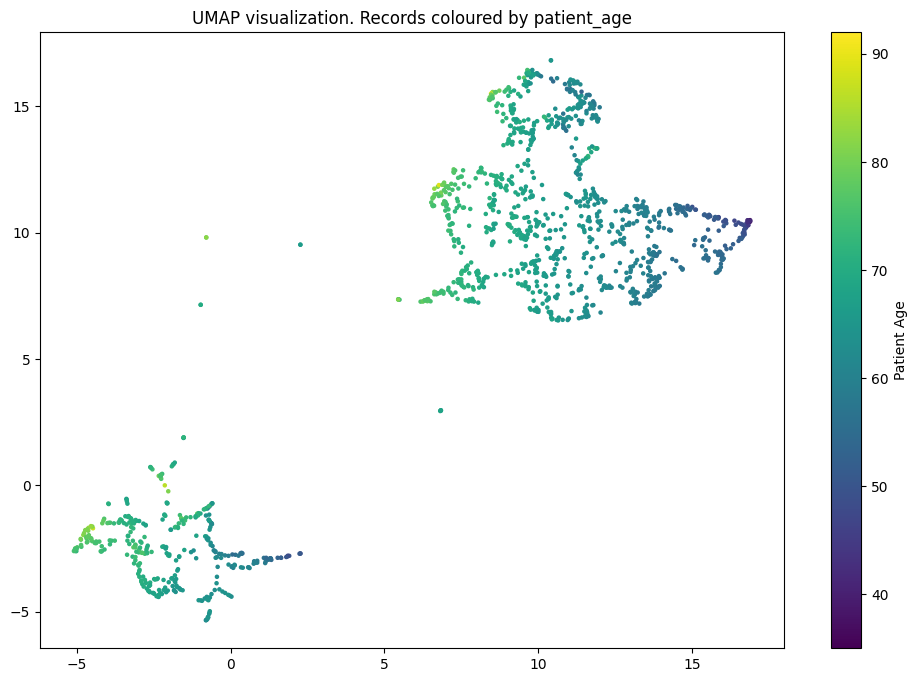

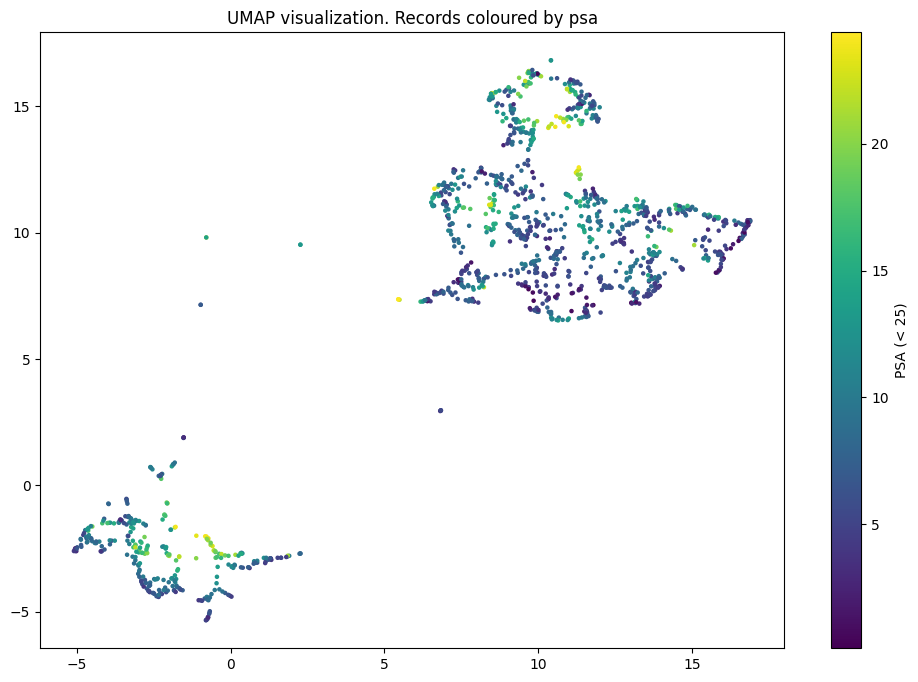

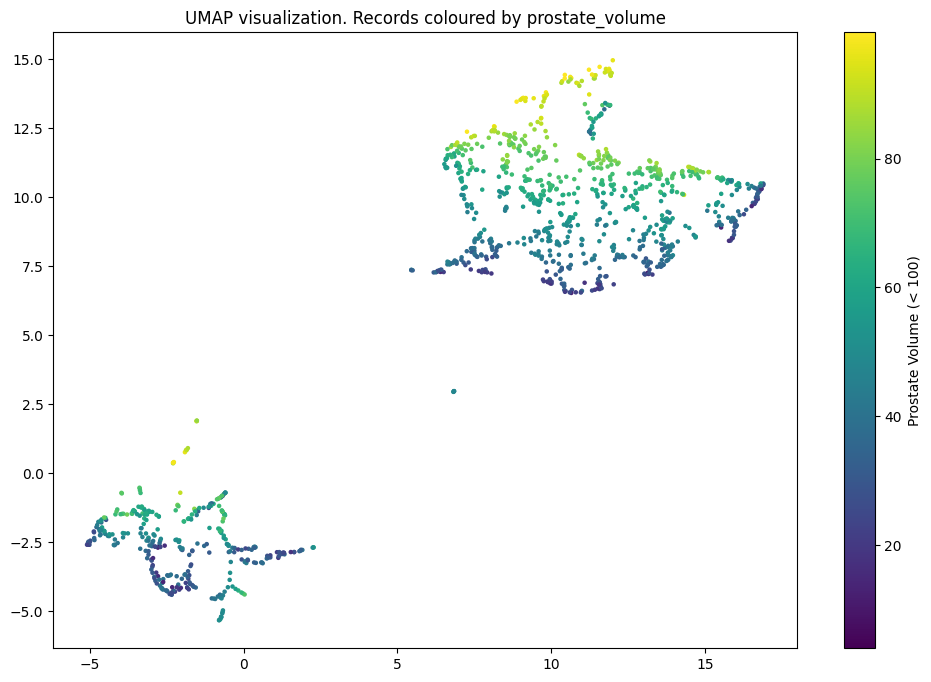

In [32]:
# Define the variables to plot and their filtering conditions
plot_vars = [
    {'label': 'patient_age', 'filter': None, 'cmap_label': 'Patient Age'},  # No filtering
    {'label': 'psa', 'filter': lambda x: x['psa'] < 25, 'cmap_label': 'PSA (< 25)'},  # Filter PSA
    {'label': 'prostate_volume', 'filter': lambda x: x['prostate_volume'] < 100, 'cmap_label': 'Prostate Volume (< 100)'}  # Filter prostate volume
]

# Loop through variables and create plots
for var in plot_vars:
    # Apply filter if specified
    if var['filter']:
        filtered_data = X_picai[var['filter'](X_picai)]
        values = filtered_data[var['label']]
        X_umap_norm_filtered = X_umap_norm[var['filter'](X_picai)]
    else:
        values = X_picai[var['label']]
        X_umap_norm_filtered = X_umap_norm

    # Create scatter plot
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_umap_norm_filtered[:, 0], X_umap_norm_filtered[:, 1], c=values, cmap='viridis', s=5)
    colorbar = plt.colorbar(scatter)
    colorbar.set_label(var['cmap_label'])
    plt.title(f'UMAP visualization. Records coloured by {var["label"]}')
    plt.show()


## 2. Dataset Partitioning and Setup

In [33]:
#Split the dataframe into reference data and incomplete data. We aim to maintain the proportion of the target value by using the 'stratity' parameter of the funtion.

reference_df, incomplete_df  = train_test_split(
    picai_psa_imputed, 
    test_size=1000, #remainder size
    stratify=picai_psa_imputed['case_csPCa'], 
    random_state = random_state+5
)

print('Shape of the reference data:', reference_df.shape, '. Mean value of the case_csPCa variable:', reference_df['case_csPCa'].mean())
print('Shape of the incomplete data:',incomplete_df.shape, '. Mean value of the case_csPCa variable:', incomplete_df['case_csPCa'].mean())

Shape of the reference data: (500, 4) . Mean value of the case_csPCa variable: 0.284
Shape of the incomplete data: (1000, 4) . Mean value of the case_csPCa variable: 0.283


In [34]:
# Divide the dataframe between the target feature and the rest

X_ref_df, y_ref = reference_df.drop(["case_csPCa"], axis=1), reference_df[["case_csPCa"]].values.flatten()
X_ref = X_ref_df.to_numpy()

norm_pipe = make_pipeline(StandardScaler()).fit(X_ref)

X_inc_df, y_inc = incomplete_df.drop(["case_csPCa"], axis=1), incomplete_df[["case_csPCa"]].values.flatten()
X_inc = X_inc_df.to_numpy()


### Reference data UMAP visualization

In [35]:
# Compute the reference UMAP from the REFERENCE data
X_reference_norm = norm_pipe.transform(X_ref_df)
manifold = umap.UMAP(random_state).fit(X_reference_norm, y_ref)
umap_ref = manifold.transform(X_reference_norm)

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [36]:
#Calculate the centroids coordinates and cluster radius of reference data for a certain density threshold.
percent_th = 0.9
density_th = 4
centroids_coord, cluster_radius = cluster_CentroidRadius_DensityPercent (umap_ref, y_ref, density_th, percent_th)

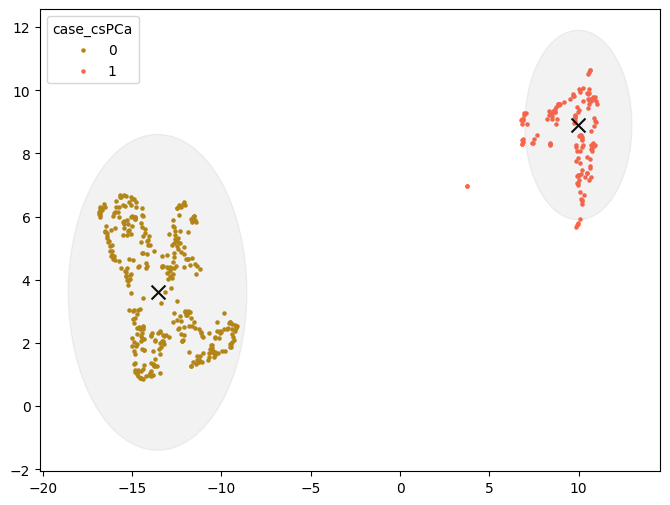

In [37]:
plt.figure(figsize=(8, 6))

class_0_idx = y_ref == 0.0
plt.scatter(umap_ref[class_0_idx, 0], umap_ref[class_0_idx, 1], c='darkgoldenrod', label='0', s=5)

class_1_idx = y_ref == 1.0
plt.scatter(umap_ref[class_1_idx, 0], umap_ref[class_1_idx, 1], c='tomato', label='1', s=5)

plt.legend(title="case_csPCa")
# plt.title('UMAP visualization - reference data and cluster areas')

for value, centroid in centroids_coord.items():
        plt.scatter(centroid[0], centroid[1], c='black', marker='x', s=100)
        circle = Circle(centroid, cluster_radius[value] , color='grey', alpha=0.1, label=f'Density = {density_th}')
        plt.gca().add_patch(circle)  
           
plt.savefig("B_central_ref_umap.png", dpi=200, bbox_inches='tight')           
plt.show()

## 3. Defining Value Ranges and Quantization

In [38]:
# Quantization pre process for PSA feature

psa_values = X_ref[:, 1]

def custom_round(value):
    rounded_value = round(value * 2) / 2
    return rounded_value


sorted_psa_values = np.sort(psa_values)
rounded_values = np.array([custom_round(val) for val in sorted_psa_values])


In [39]:
minmax_psa = [0, 100]
step_psa = 0.5

#Obtain min and max values of each feature
min_values = np.min(X_ref, axis=0)
max_values = np.max(X_ref, axis=0)

minmax_age = [min_values[0], max_values[0]]
minmax_pvol = [min_values[2], max_values[2]]

step_age = 1
step_pvol = 1

minmax_v = [minmax_age, minmax_psa, minmax_pvol]
step_v = [step_age, step_psa, step_pvol]

## 4. Hyperparameter Tuning for Synthetic Data Validation

In [40]:
#Compute the feature disparcity of the reference data in order to define the relibility score for synthetic data. 
#Compute the difference between the mean feature value of the k-nearest neighbours and the value of each sample. 

n_neigh = 10
nbrs = NearestNeighbors(n_neighbors=n_neigh, radius = 0.5, algorithm='auto').fit(umap_ref)
distances, indices = nbrs.kneighbors(umap_ref) #Obtain the distances and the indices of the closest neighbours on the reference UMAP

miss_idx = 0
mean_neighbor_age = np.mean(X_ref[indices, miss_idx], axis=1)
sample_age = X_ref[:,miss_idx]
feature_dis_age = abs(mean_neighbor_age - sample_age)

miss_idx = 1
mean_neighbor_psa = np.mean(X_ref[indices, miss_idx], axis=1)
sample_psa = X_ref[:,miss_idx]
feature_dis_psa = abs(mean_neighbor_psa - sample_psa)

miss_idx = 2
mean_neighbor_pvol = np.mean(X_ref[indices, miss_idx], axis=1)
sample_pvol = X_ref[:,miss_idx]
feature_dis_pvol = abs(mean_neighbor_pvol - sample_pvol)

In [41]:
eps_age = round(np.mean(feature_dis_age))
eps_psa = round(np.mean(feature_dis_psa))
eps_pvol = round(np.mean(feature_dis_pvol))
print('Epsilon for patient age:', eps_age)
print('Epsilon for PSA:', eps_psa)
print('Epsilon for prostate volume:', eps_pvol)
eps_v = [eps_age, eps_psa, eps_pvol]

Epsilon for patient age: 1
Epsilon for PSA: 4
Epsilon for prostate volume: 6


## 5. Iterative Synthetic Data Generation

In [42]:
random_val = 23 
missing_data = X_inc_df #DataFrame with the entries that will be uncompleted
X_reference = X_ref_df #Reference DataFrame
y_reference = y_ref #Reference output variable
percent_th = 0.9 #Percentage of cluster samples inside the cluster area
density_th = 4 #Cluster area density of samples
n_neigh = 10 #Number of considered neighbours for reliability score
sel_reliability = 1 #Chosen reliability for chosen generated samples
minmax_data = minmax_v #Min and max values for the M range for each feature
step_data = step_v #Step on the M range for eacg feature
eps_data = eps_v #Epsilon values for each feature


#COMPUTE REFERENCE UMAP
X_ref = X_reference.to_numpy() #Array with the reference data
norm_pipe = make_pipeline(StandardScaler()).fit(X_ref) #Normalization pipe
X_reference_norm = norm_pipe.transform(X_reference)
manifold = umap.UMAP(random_state=random_val).fit(X_reference_norm, y_reference)
umap_reference = manifold.transform(X_reference_norm)

#Calculate the CENTROIDS coordinates and cluster radius of reference data for a certain density threshold and percentage threshold
centroids_coord, cluster_radius = cluster_CentroidRadius_DensityPercent (umap_reference, y_reference, density_th, percent_th)

for index in range (2,-1, -1): #loop for each feature
    #In the first iteration, missing_data is the feature DataFrame of the selected uncompleted data. 
    #During the other iterations, missing data is a feature DataFrame with 1 or two synthetic columns.  
    uncompleted_df = missing_data.copy() 
    print(len(missing_data))
    
    uncompleted_df.iloc[:,index] = np.nan #Substitute a column by NaN
    
    #Obtain the parameters for the M range
    minmax_feat = minmax_data[index]
    min_value =  minmax_feat[0]
    max_value = minmax_feat[1]
    step = step_data[index]
    eps = eps_data[index]
    
    partially_synth_data_feature = pd.DataFrame() #Partially synth. DataFrame corresponding to a missing feature. 
    partially_synth_data_feature_cluster = pd.DataFrame()
    
    #loop for all the values in M range
    for target_value in np.arange(min_value, max_value+1, step):
        
        now = datetime.datetime.now()
        print('Feature:', index, '. Target value:', target_value, now.time())
        
        generated_data_df = uncompleted_df #The generated data is based on the uncompleted data
        generated_data_df.iloc[:,index] = target_value #Complete the data with a target value

        generated_data_df = generated_data_df.drop_duplicates()
        
        X_gen_norm = norm_pipe.transform(generated_data_df) #Normalize the array of uncompleted data
        umap_gen = manifold.transform(X_gen_norm) #UMAP coordinates
       
        #DATA VALIDATION:  
        
        # STEP A: AGE RELIAVILITY
        nbrs = NearestNeighbors(n_neighbors=n_neigh, radius = 0.5, algorithm='auto').fit(umap_reference)
        distances, indices = nbrs.kneighbors(umap_gen) #Obtain the distances and the indices of the closest neighbours on the reference UMAP
        mean_neighbor_feature = np.mean(X_ref[indices, index], axis=1) #Compute the mean value of the feature for the nearest nesighbours
        feature_distances = np.array([abs(mean_feature - target_value) for mean_feature in mean_neighbor_feature])

        feature_reliabilities = np.where(
        feature_distances <= eps, 1,
        np.where(feature_distances <= 2*eps, 0.9,
                 np.where(feature_distances <= 3*eps, 0.8,
                          np.where(feature_distances <= 4*eps, 0.7,
                                   np.where(feature_distances <= 5*eps, 0.6,
                                            np.where(feature_distances <= 6*eps, 0.5, 0.2))))))  # Compute age reliabilities
        
        valid_indexes = np.where(feature_reliabilities == sel_reliability)[0]
        
        #Validated partially synthetic data for each Target Value:
        partially_synth_data_targetValue = generated_data_df.iloc[valid_indexes]
        
        #Add the synthetic data generated with every target age
        partially_synth_data_feature = pd.concat([partially_synth_data_feature, partially_synth_data_targetValue], ignore_index=True)
        
        #Update the DataFrame "missing_data" from which the next iteration will start
        missing_data = partially_synth_data_feature

               
        # STEP B: CLUSTER VALIDATION 
        if index == 0: #ONLY IN THE LAST ITERATION
            cluster_vector = [] #Equivalent to case_csPCa. If nan, means the sample does not have cluster validation
            
            # Compute distances to centroids for all points
            distances_to_centroids = np.array([np.linalg.norm(umap_gen - centroid, axis=1) for centroid in centroids_coord.values()])

            # Find index of closest centroid for each point
            closest_centroid_indices = np.argmin(distances_to_centroids, axis=0)

            # Initialize cluster_vector with np.nan
            cluster_vector = np.full(len(umap_gen), np.nan)

            # Update cluster_vector for points within cluster radius
            for idx, min_distance in enumerate(np.min(distances_to_centroids, axis=0)):
                closest_centroid = closest_centroid_indices[idx]
                if min_distance < cluster_radius[closest_centroid]:
                    cluster_vector[idx] = closest_centroid      
            generated_data_cluster_df = generated_data_df.copy()
            generated_data_cluster_df['case_csPCa'] = cluster_vector   

            #Get the positions that did not pass cluster validation. Position 'True' means the sample did not pass cluster validation
            non_validated_pos = np.isnan(cluster_vector) 
            
            #Get the synthetic samples with valid indexes (selected reliability)
            partially_synth_data_targetValue_cluster = generated_data_cluster_df.iloc[valid_indexes]
            #Add the synthetic data generated with every target age
            partially_synth_data_feature_cluster = pd.concat([partially_synth_data_feature_cluster, partially_synth_data_targetValue_cluster], ignore_index=True)
            # Drop rows where 'case_csPCa' is NaN (did not pass cluster validation)
            partially_synth_data_feature_cluster = partially_synth_data_feature_cluster.dropna(subset=['case_csPCa'])
            
        
#Print the results in a file 
fully_synthetic_data = partially_synth_data_feature_cluster
output_file = 'fully_synthetic_data.csv'
fully_synthetic_data.to_csv(output_file, index=False)
print('Done!')

/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


1000
Feature: 2 . Target value: 4.0 18:40:28.745250


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Feature: 2 . Target value: 5.0 18:40:29.106976


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


...

Feature: 0 . Target value: 86.0 18:53:55.891069


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Feature: 0 . Target value: 87.0 18:54:01.246676


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Done!


In [43]:
fully_synthetic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92551 entries, 0 to 92550
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_age      92551 non-null  float64
 1   psa              92551 non-null  float64
 2   prostate_volume  92551 non-null  float64
 3   case_csPCa       92551 non-null  float64
dtypes: float64(4)
memory usage: 2.8 MB


/Users/marionaalmato/miniconda3/envs/I2R_project/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


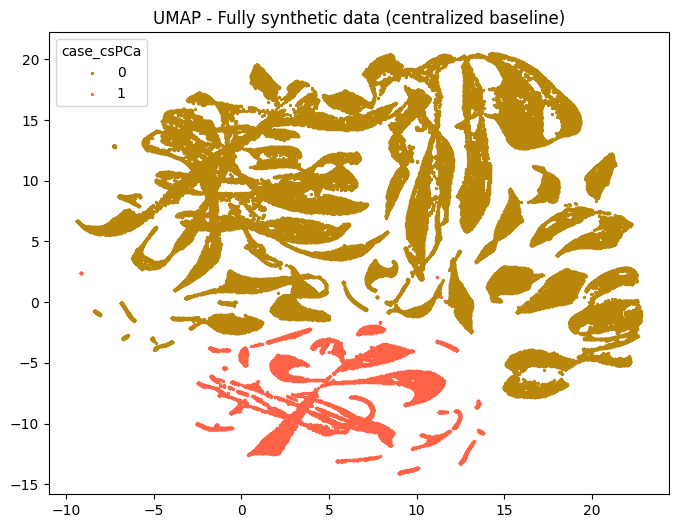

In [44]:
# UMAP plot of the fully synthetic dataset
X_fully = fully_synthetic_data.drop(["case_csPCa"], axis=1)
y_fully = fully_synthetic_data["case_csPCa"].values.flatten()

norm_pipe_fully = make_pipeline(StandardScaler()).fit(X_fully)
X_fully_norm = norm_pipe_fully.transform(X_fully)

manifold_fully = umap.UMAP(random_state=random_state).fit(X_fully_norm, y_fully)
umap_fully = manifold_fully.transform(X_fully_norm)

plt.figure(figsize=(8, 6))
class_0_idx = y_fully == 0.0
plt.scatter(umap_fully[class_0_idx, 0], umap_fully[class_0_idx, 1],
            c='darkgoldenrod', label='0', s=2)
class_1_idx = y_fully == 1.0
plt.scatter(umap_fully[class_1_idx, 0], umap_fully[class_1_idx, 1],
            c='tomato', label='1', s=2)
plt.legend(title="case_csPCa")
plt.title("UMAP - Fully synthetic data (centralized baseline)")
plt.savefig("B_central_synth_umap.png", dpi=200, bbox_inches='tight')
plt.show()

In [45]:
# Fidelity (KS distance) and Utility (TSTR)
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# Fidelity
ks_results = {}
for feature in ['patient_age', 'psa', 'prostate_volume']:
    stat, _ = ks_2samp(picai_psa_imputed[feature], fully_synthetic_data[feature])
    ks_results[feature] = stat

print('KS distance per feature:')
for f, v in ks_results.items():
    print(f'  {f}: {v:.4f}')
print(f'Mean KS distance: {sum(ks_results.values()) / len(ks_results):.4f}')

# Utility (TSTR with Random Forest)
X_real = picai_psa_imputed.drop('case_csPCa', axis=1)
y_real = picai_psa_imputed['case_csPCa']
_, X_test_real, _, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, stratify=y_real, random_state=42
)

X_synth = fully_synthetic_data.drop('case_csPCa', axis=1)
y_synth = fully_synthetic_data['case_csPCa']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_synth, y_synth)
y_pred = clf.predict(X_test_real)
y_proba = clf.predict_proba(X_test_real)[:, 1]

print()
print(f'TSTR AUC:      {roc_auc_score(y_test_real, y_proba):.4f}')
print(f'TSTR F1:       {f1_score(y_test_real, y_pred):.4f}')
print(f'TSTR Accuracy: {accuracy_score(y_test_real, y_pred):.4f}')

print()
print(f'Total fully synthetic samples: {len(fully_synthetic_data)}')

KS distance per feature:
  patient_age: 0.1073
  psa: 0.3954
  prostate_volume: 0.3265
Mean KS distance: 0.2764

TSTR AUC:      0.7248
TSTR F1:       0.3911
TSTR Accuracy: 0.7578

Total fully synthetic samples: 92551
